In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.core.pylabtools import figsize

In [3]:
df = pd.read_csv('online_shoppers_intention.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

У нас довольно хороший для анализа изначально датасет: нет пропущенных значений, типы данных правильные. Посмотрим на статистики по колонкам датасета.

In [7]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


Наша целевая переменная - Revenue. Она показывает совершил пользователь покупку в текущую сессию или нет. То есть тип она имеет boolean. Посмотрим на распределение значений True и False.

In [12]:
df['Revenue'].value_counts(normalize=True)

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64

Большинство значений False (почти 85%). В целом, это логично, так как чаще всего пользователи не совершают покупки, а просто просматривают страницы сайта. Наша задача - выяснить, что же все-таки заставляет пользователя сделать покупку, как по его поведению это можно предсказать и как онлайн магазинам можно модифицировать свои сайты, чтобы увеличить конверцию посетителей в покупателей.

Посмотрим как в целом признаки влияют на целевую переменную с помощью корреляционной матрицы.

<Axes: >

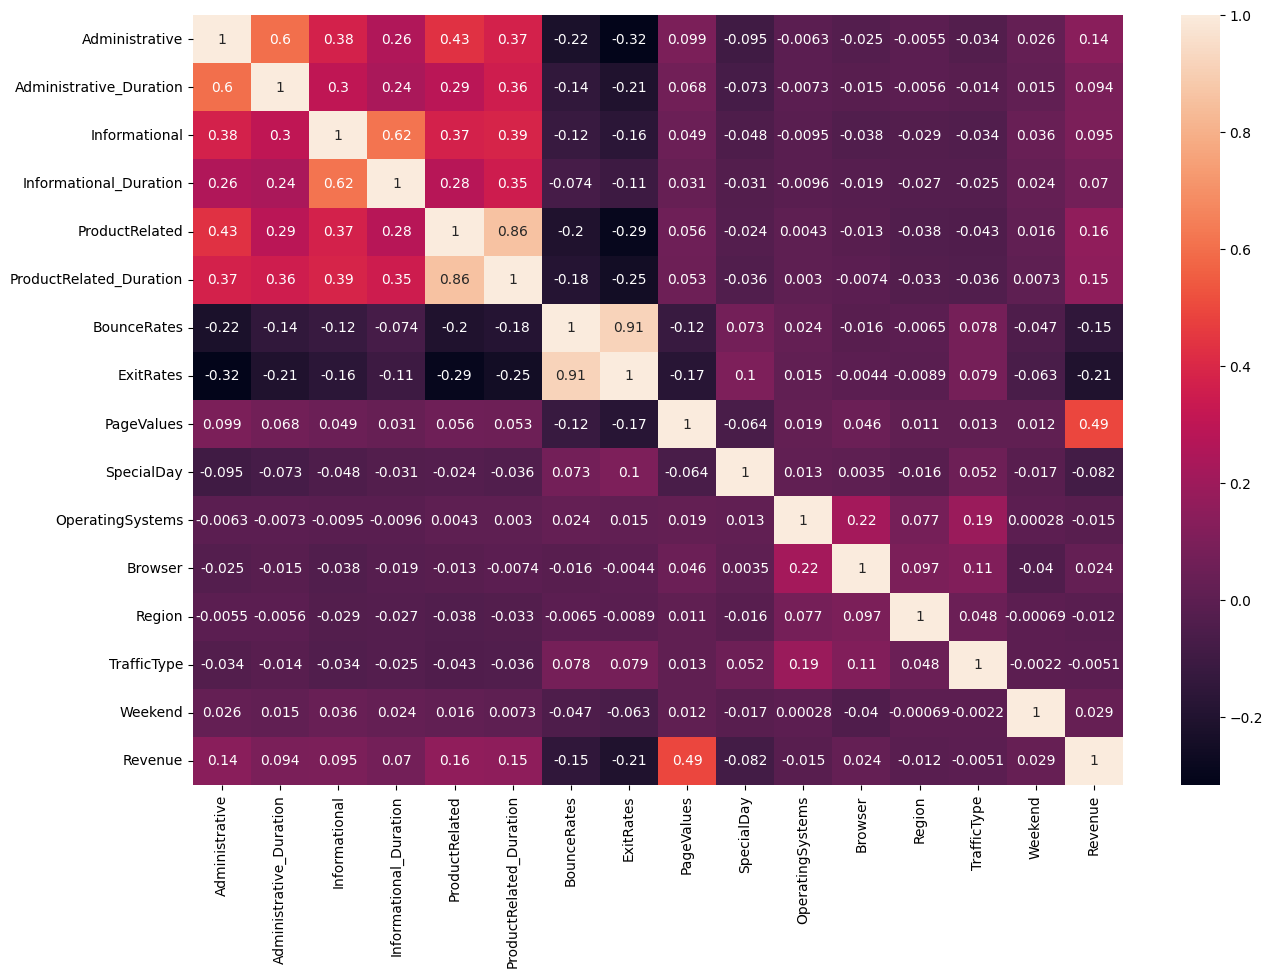

In [26]:
figsize(15,10)

sns.heatmap(df.corr(numeric_only = True), annot=True)

Тееперь мы видим, как влияют различные признаки из нашего датасета на целевую переменную Revenue и друг на друга. Можно заметить, что наибольшая положительная корреляция у Revenue с PageValues (признак, показывающий, насколько ценными с точки зрения покупки были страницы, по которым двигался пользователь). Самая большая отрицательная корреляция с целевой переменной у ExitRates (средняя доля выходов с каждой страницы сессии). Очень высокая корреляция (0.91) у ExitRates и BounceRates (показатель того, насколько пользовательская сессия характеризуется быстрым уходом без значимого взаимодействия с сайтом) - оба признака характеризуют уход пользователя с сайта. Еще одна высокая корреляция между признакими ProductRelsted_Duration и ProductRelated (что в целом максимально логично, так как 1 это время проведенное на страницах с товарами, а 2 количество страниц с товарами).